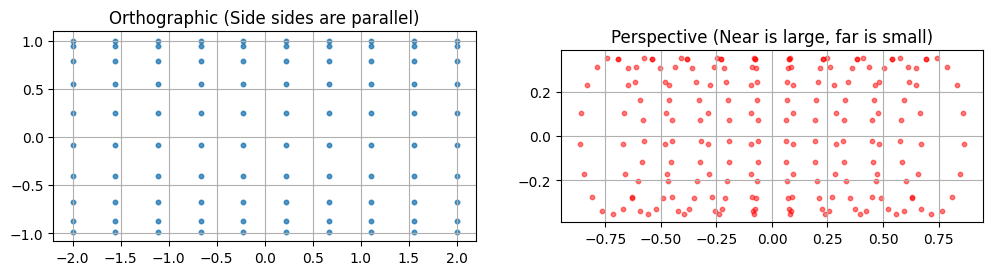

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def get_perspective_matrix(fov, aspect, near, far):
    f = 1.0 / np.tan(np.deg2rad(fov) / 2.0)
    return np.array([
        [f/aspect, 0, 0, 0],
        [0, f, 0, 0],
        [0, 0, -(far+near)/(far-near), -(2*far*near)/(far-near)],
        [0, 0, -1, 0]
    ])

def project_points(points, matrix):
    # 转换为齐次坐标 (N, 4)
    points_homo = np.hstack([points, np.ones((points.shape[0], 1))])
    # 矩阵变换
    projected = points_homo @ matrix.T
    # 关键步骤：透视除法 (w分量在第四列)
    w = projected[:, 3:4]
    ndc = projected[:, :3] / w
    return ndc

# 1. 生成圆柱体数据 (横放：轴线沿X轴)
z_center = -5
x_range = np.linspace(-2, 2, 10)  # 圆柱体长度
theta = np.linspace(0, 2*np.pi, 20)
X, Theta = np.meshgrid(x_range, theta)
Y = np.cos(Theta)
Z = np.sin(Theta) + z_center
points = np.vstack([X.flatten(), Y.flatten(), Z.flatten()]).T

# 2. 计算两种投影
# 透视投影
p_mat = get_perspective_matrix(60, 1.0, 0.1, 100)
points_persp = project_points(points, p_mat)

# 正交投影 (简单取XY)
points_ortho = points.copy()

# 3. 绘图对比
fig = plt.figure(figsize=(12, 5))

# 正交投影图
ax1 = fig.add_subplot(121)
ax1.scatter(points_ortho[:, 0], points_ortho[:, 1], s=10, alpha=0.5)
ax1.set_title("Orthographic (Side sides are parallel)")
ax1.set_aspect('equal')
ax1.grid(True)

# 透视投影图
ax2 = fig.add_subplot(122)
ax2.scatter(points_persp[:, 0], points_persp[:, 1], s=10, color='red', alpha=0.5)
ax2.set_title("Perspective (Near is large, far is small)")
ax2.set_aspect('equal')
ax2.grid(True)

plt.show()
